In [2]:
# 1. Importaciones básicas y configuración de entorno

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("default")

# Asegurar que estamos en la raíz del proyecto (no en /notebooks)
cwd = os.getcwd()
if cwd.endswith("notebooks"):
    os.chdir("..")
    print("Cambiando directorio de trabajo a la raíz del proyecto.")
print("Working dir:", os.getcwd())

df = pd.read_csv("data/05_model_input/nhanes_features_rich_v1.csv")

print(df.shape)
df.head()


Cambiando directorio de trabajo a la raíz del proyecto.
Working dir: c:\Users\Ella es ella\Documents\kedro_projects\nhanes-htn
(11268, 25)


,id,age_years,gender_code,race_ethnicity_code,education_level_code,income_poverty_ratio,bmi,waist_cm,sedentary_minutes,cycle,...,secondhand_smoke_home,secondhand_smoke_inside,smoke_inside_freq_cat,alcohol_level,binge_drinker,drinks_per_week,sleep_duration_cat,probable_OSA,depression_score,depression_severity
0,83732,62,1,3,5,4.39,27.8,101.1,480.0,2015_2016,...,0.0,NaN,NaN,low,NaN,1.00,6-7h,0.0,1.0,none
1,83733,53,1,3,3,1.32,30.8,107.9,300.0,2015_2016,...,1.0,1.0,NaN,unknown,NaN,NaN,7-8h,0.0,2.0,none
2,83734,78,1,3,3,1.51,28.8,116.5,480.0,2015_2016,...,1.0,1.0,NaN,unknown,NaN,NaN,NaN,0.0,1.0,none
3,83735,56,2,3,5,5.00,42.4,110.1,480.0,2015_2016,...,0.0,NaN,NaN,low,NaN,0.75,6-7h,0.0,13.0,moderate
4,83736,42,2,4,4,1.23,20.3,80.4,540.0,2015_2016,...,1.0,1.0,1-3_days,low,NaN,0.25,NaN,0.0,8.0,mild


In [3]:
# 3. Definir target y columnas predictoras
TARGET = "HTN_label"

# Quitamos id y la etiqueta
feature_cols = [c for c in df.columns if c not in ["id", TARGET]]

X = df[feature_cols].copy()
y = df[TARGET].copy()


In [4]:
# 3.1 Separación numéricas / categóricas (para usar ColumnTransformer)
import numpy as np

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['age_years', 'gender_code', 'race_ethnicity_code', 'education_level_code', 'income_poverty_ratio', 'bmi', 'waist_cm', 'sedentary_minutes', 'current_smoker', 'former_smoker', 'never_smoker', 'pack_years_aprox', 'secondhand_smoke_home', 'secondhand_smoke_inside', 'binge_drinker', 'drinks_per_week', 'probable_OSA', 'depression_score']
Categóricas: ['cycle', 'smoke_inside_freq_cat', 'alcohol_level', 'sleep_duration_cat', 'depression_severity']


In [6]:
# 4. Train–test split + Pipeline de preprocesamiento
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [7]:
# 4.1 Preprocesamiento (imputación + escalado + one-hot)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


In [8]:
# 5. Reentrenar los modelos con las nuevas features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

log_reg_clf.fit(X_train, y_train)

y_pred = log_reg_clf.predict(X_test)
y_proba = log_reg_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.92      0.67      0.78      1794
           1       0.38      0.77      0.51       460

    accuracy                           0.69      2254
   macro avg       0.65      0.72      0.64      2254
weighted avg       0.81      0.69      0.72      2254

ROC-AUC: 0.7755707430565654


In [9]:
# 5.1 RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            class_weight="balanced_subsample",
        )),
    ]
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC RF:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1794
           1       0.42      0.05      0.09       460

    accuracy                           0.79      2254
   macro avg       0.61      0.52      0.49      2254
weighted avg       0.72      0.79      0.72      2254

ROC-AUC RF: 0.7584878338422762


                          feature  importance
0                  num__age_years    0.234240
6                   num__waist_cm    0.122092
5                        num__bmi    0.110761
4       num__income_poverty_ratio    0.093343
7          num__sedentary_minutes    0.072520
17          num__depression_score    0.054783
2        num__race_ethnicity_code    0.045359
3       num__education_level_code    0.041242
11          num__pack_years_aprox    0.025264
15           num__drinks_per_week    0.025180
1                num__gender_code    0.019827
27   cat__sleep_duration_cat_7-8h    0.014534
12     num__secondhand_smoke_home    0.012746
16              num__probable_OSA    0.012130
29    cat__sleep_duration_cat_>8h    0.011962
26   cat__sleep_duration_cat_6-7h    0.011737
18           cat__cycle_2015_2016    0.008941
19           cat__cycle_2017_2018    0.008857
33  cat__depression_severity_none    0.008648
13   num__secondhand_smoke_inside    0.008147


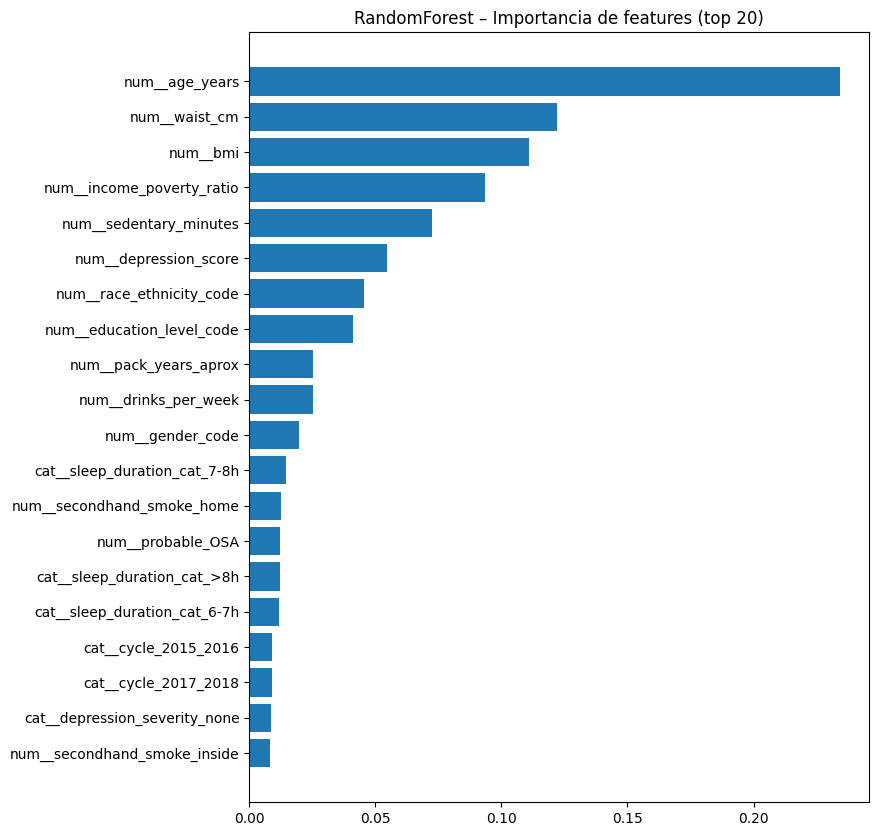

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = rf_clf.named_steps["preprocess"].get_feature_names_out()
importances = rf_clf.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(fi_df.head(20))

plt.figure(figsize=(8, 10))
plt.barh(fi_df["feature"].head(20), fi_df["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("RandomForest – Importancia de features (top 20)")
plt.show()


In [14]:
# Get coefficients from the logistic regression model inside the pipeline
coef = log_reg_clf.named_steps["model"].coef_[0]
fi_log = pd.DataFrame({
    "feature": log_reg_clf.named_steps["preprocess"].get_feature_names_out(),
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

fi_log.head(20)

,feature,coef,abs_coef
0,num__age_years,1.067515,1.067515
21,cat__smoke_inside_freq_cat_4-7_days,-0.346965,0.346965
34,cat__depression_severity_severe,0.273959,0.273959
32,cat__depression_severity_moderately_severe,-0.271951,0.271951
24,cat__alcohol_level_moderate,-0.234660,0.234660
22,cat__alcohol_level_heavy,0.196670,0.196670
23,cat__alcohol_level_low,-0.166007,0.166007
5,num__bmi,0.164259,0.164259
6,num__waist_cm,0.157961,0.157961
2,num__race_ethnicity_code,0.154286,0.154286


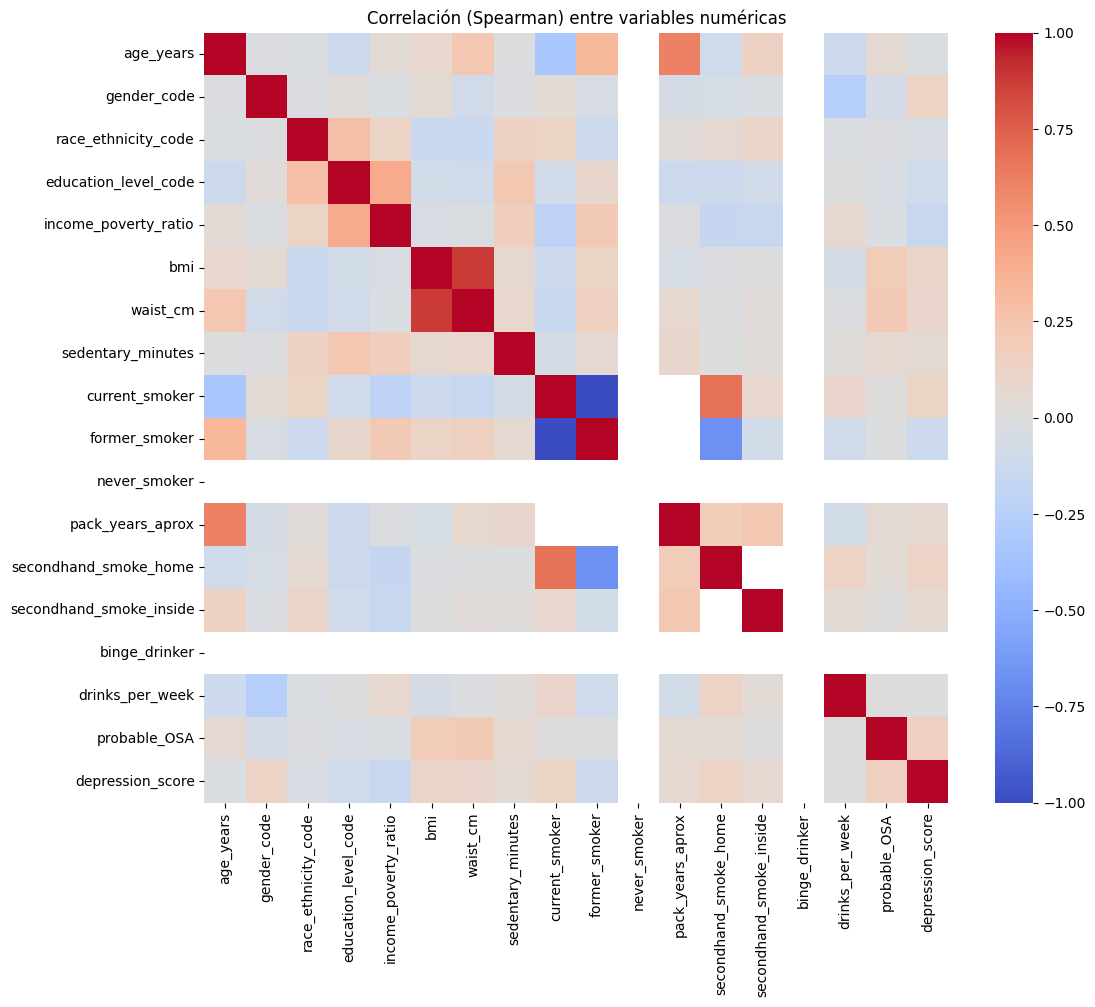

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = X_train.select_dtypes(include=[np.number]).columns
corr = X_train[numeric_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlación (Spearman) entre variables numéricas")
plt.show()

In [ ]:
from kedro.io import DataCatalog
from kedro.config import ConfigLoader
# o, más simple en el notebook, usa `catalog.load("nhanes_features_rich")`

__________

In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

df = pd.read_csv("data/05_model_input/nhanes_features_rich_v1.csv")

df["HTN_label"].value_counts(normalize=True)

HTN_label
0    0.795793
1    0.204207
Name: proportion, dtype: float64

In [18]:
target_col = "HTN_label"

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42,
)


In [19]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_cols, categorical_cols


(['id',
  'age_years',
  'gender_code',
  'race_ethnicity_code',
  'education_level_code',
  'income_poverty_ratio',
  'bmi',
  'waist_cm',
  'sedentary_minutes',
  'current_smoker',
  'former_smoker',
  'never_smoker',
  'pack_years_aprox',
  'secondhand_smoke_home',
  'secondhand_smoke_inside',
  'binge_drinker',
  'drinks_per_week',
  'probable_OSA',
  'depression_score'],
 ['cycle',
  'smoke_inside_freq_cat',
  'alcohol_level',
  'sleep_duration_cat',
  'depression_severity'])

In [20]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


In [21]:
rf_balanced = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",   # aquí está el peso de clase
)


In [22]:
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", rf_balanced),
    ]
)


In [23]:
rf_pipe.fit(X_train, y_train)

y_pred = rf_pipe.predict(X_test)
y_proba = rf_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.99      0.88      2691
           1       0.47      0.05      0.08       690

    accuracy                           0.79      3381
   macro avg       0.64      0.52      0.48      3381
weighted avg       0.73      0.79      0.72      3381

ROC-AUC: 0.7631678865138223
Confusion matrix:
 [[2655   36]
 [ 658   32]]


In [24]:
def evaluate_thresholds(y_true, y_proba, thresholds):
    rows = []
    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        prec = precision_score(y_true, y_pred_thr, zero_division=0)
        rec = recall_score(y_true, y_pred_thr, zero_division=0)
        f1 = f1_score(y_true, y_pred_thr, zero_division=0)
        rows.append((thr, prec, rec, f1))
    return pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])


In [25]:
thresholds = np.arange(0.10, 0.91, 0.05)
thr_df = evaluate_thresholds(y_test, y_proba, thresholds)
thr_df


,threshold,precision,recall,f1
0,0.10,0.296763,0.956522,0.452986
1,0.15,0.323899,0.895652,0.475751
2,0.20,0.345960,0.794203,0.481970
3,0.25,0.367514,0.649275,0.469356
4,0.30,0.374109,0.456522,0.411227
5,0.35,0.426136,0.326087,0.369458
6,0.40,0.445545,0.195652,0.271903
7,0.45,0.474026,0.105797,0.172986
8,0.50,0.470588,0.046377,0.084433
9,0.55,0.468750,0.021739,0.041551


In [26]:
# Filtrar por recall mínimo deseado
candidate = thr_df[thr_df["recall"] >= 0.70]

if not candidate.empty:
    best_row = candidate.sort_values("f1", ascending=False).iloc[0]
else:
    best_row = thr_df.sort_values("f1", ascending=False).iloc[0]

best_thr = best_row["threshold"]
best_row


threshold    0.200000
precision    0.345960
recall       0.794203
f1           0.481970
Name: 2, dtype: float64

In [27]:
y_pred_best = (y_proba >= best_thr).astype(int)

print(f"Umbral elegido: {best_thr:.2f}")
print(classification_report(y_test, y_pred_best))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("ROC-AUC (no cambia con el umbral):", roc_auc_score(y_test, y_proba))


Umbral elegido: 0.20
              precision    recall  f1-score   support

           0       0.92      0.62      0.74      2691
           1       0.35      0.79      0.48       690

    accuracy                           0.65      3381
   macro avg       0.63      0.70      0.61      3381
weighted avg       0.80      0.65      0.69      3381

Confusion matrix:
 [[1655 1036]
 [ 142  548]]
ROC-AUC (no cambia con el umbral): 0.7631678865138223


In [28]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

hgb = HistGradientBoostingClassifier(
    max_depth=None,
    learning_rate=0.05,
    max_iter=300,
    random_state=42,
)

# sample_weight balanceado:
sample_weight = compute_sample_weight("balanced", y_train)

hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", hgb),
    ]
)

hgb_pipe.fit(X_train, y_train, model__sample_weight=sample_weight)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Comparación de modelos de clasificación de HTA: umbral estándar vs umbral optimizado

### 1. Contexto

- Variable objetivo: `HTN_label` (0 = sin hipertensión, 1 = hipertensión).
- Desbalance de clases:  
  - Clase 0: ~79,6 %  
  - Clase 1: ~20,4 %
- Modelo: RandomForestClassifier dentro de un `Pipeline` con preprocesamiento.
- Métrica global de discriminación: ROC–AUC ≈ **0,76** (no cambia al modificar el umbral).

---

### 2. Modelo base (umbral estándar 0,50)

#### 2.1 Métricas por clase

- **Clase 0 (no HTA)**
  - Precision: **0,80**
  - Recall: **0,99**
  - F1-score: **0,88**

- **Clase 1 (HTA)**
  - Precision: **0,47**
  - Recall: **0,05**
  - F1-score: **0,08**

- **Métricas globales**
  - Accuracy: **0,79**
  - ROC–AUC: **0,76**

#### 2.2 Matriz de confusión (umbral 0,50)

|                      | Predicho 0 | Predicho 1 |
|----------------------|-----------:|-----------:|
| **Real 0 (no HTA)**  | 2655       | 36         |
| **Real 1 (HTA)**     | 658        | 32         |

#### 2.3 Interpretación

1. El modelo acierta casi todos los casos sin HTA (recall 0 ≈ 0,99).  
2. Sin embargo, prácticamente **no identifica hipertensos** (recall 1 ≈ 0,05).  
3. La accuracy alta (0,79) está dominada por la clase mayoritaria y **es engañosa** en términos clínicos: funciona casi como decir “casi todos son no hipertensos”.

---

### 3. Modelo con umbral optimizado (umbral 0,20)

El umbral se eligió buscando maximizar el F1 de la clase positiva (HTA).

#### 3.1 Métricas por clase

- **Clase 0 (no HTA)**
  - Precision: **0,92**
  - Recall: **0,62**
  - F1-score: **0,74**

- **Clase 1 (HTA)**
  - Precision: **0,35**
  - Recall: **0,79**
  - F1-score: **0,48**

- **Métricas globales**
  - Accuracy: **0,65**
  - ROC–AUC: **0,76** (se mantiene igual; solo cambia el punto de la curva).

#### 3.2 Matriz de confusión (umbral 0,20)

|                      | Predicho 0 | Predicho 1 |
|----------------------|-----------:|-----------:|
| **Real 0 (no HTA)**  | 1655       | 1036       |
| **Real 1 (HTA)**     | 142        | 548        |

#### 3.3 Interpretación

1. El modelo ahora **recupera ~79 % de los hipertensos** (recall 1 ≈ 0,79), un salto muy relevante frente al 5 % inicial.  
2. El precio a pagar es:
   1. Disminución de accuracy global (0,79 → 0,65).  
   2. Aumento de falsos positivos (personas sin HTA clasificadas como HTA).  
3. La precisión en positivos (0,35) indica que alrededor de 1 de cada 3 pacientes etiquetados como “HTA” será realmente hipertenso; los demás serían candidatos a confirmación diagnóstica (tamizaje).

---

### 4. Comparación directa

1. **Capacidad de ranking (ROC–AUC)**  
   - Se mantiene ~0,76 en ambos escenarios: el modelo tiene una discriminación moderada.  
   - Cambiar el umbral no modifica el AUC, solo la posición en la curva ROC.

2. **Detección de HTA (clase 1)**  
   - Umbral 0,50: recall **0,05** → el modelo prácticamente no sirve para detectar hipertensos.  
   - Umbral 0,20: recall **0,79** → el modelo se vuelve útil como herramienta de **tamizaje**.

3. **Coste en términos de falsos positivos**  
   - Umbral 0,50: el modelo casi no etiqueta a nadie como hipertenso → pocos falsos positivos, muchos falsos negativos.  
   - Umbral 0,20: aumenta el número de falsos positivos (baja la precisión), pero reduce drásticamente los falsos negativos.

---

### 5. Argumento y justificación del umbral elegido

1. Desde la perspectiva clínica y de salud pública, en el contexto de hipertensión arterial:
   1. Es mucho más aceptable **sobredetectar** y luego confirmar con mediciones adicionales, que **dejar sin detectar** a personas hipertensas.  
   2. Los falsos positivos implican principalmente más evaluación y seguimiento, mientras que los falsos negativos implican riesgo sostenido de eventos cardiovasculares no prevenidos.

2. Con tus datos:
   1. El modelo base (umbral 0,50) maximiza la comodidad estadística (accuracy alta), pero **no cumple el objetivo clínico**: casi todos los pacientes con HTA quedan sin identificar.  
   2. El modelo con umbral 0,20 reduce la accuracy, pero:
      - Aumenta de forma muy relevante la sensibilidad para HTA.  
      - Mantiene una precisión aceptable en la clase 0 (0,92), por lo que la mayoría de los “no HTA” predichos siguen siendo verdaderos no hipertensos.

3. Por tanto, para el propósito del proyecto (detección de riesgo de hipertensión):
   1. Es más razonable **reportar y discutir el modelo optimizado** (umbral 0,20) como configuración principal,  
   2. Utilizando el modelo base como comparación para mostrar el impacto del desbalance de clases y la necesidad de ajustar el umbral.
